<a href="https://colab.research.google.com/github/Integenpiyush/churn-prediction-catboost/blob/main/notebooks/03_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install catboost optuna shap wandb imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, precision_score,
                              recall_score, classification_report,
                              RocCurveDisplay, ConfusionMatrixDisplay)

print("All imports successful")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.6 MB/s eta 0:00:00
All imports successful


In [4]:
# Load preprocessed data

with open('preprocessed_data.pkl','rb') as f:
  X_train,X_test,y_train,y_test = pickle.load(f)

print("Data loaded successfully")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())
print("y_test distribution:", y_test.value_counts().to_dict())

Data loaded successfully
X_train shape: (8260, 29)
X_test shape: (1407, 29)
y_train distribution: {0: 4130, 1: 4130}
y_test distribution: {0: 1033, 1: 374}


## Day 10 — Baseline Model Comparison
Training 4 models with default parameters.
Goal: establish baseline performance before Optuna tuning.
Models: Logistic Regression, Random Forest, XGBoost, CatBoost
Primary metric: AUC-ROC (handles class imbalance well)
Secondary metric: F1-score (balances precision and recall)

In [5]:
# Define evaluation function
def evaluate_model(name,model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:,1]


  results = {'Model':name,
             'Accuracy':round(accuracy_score(y_test,y_pred),4),
             'Precision':round(precision_score(y_test,y_pred),4),
             'Recall':round(recall_score(y_test,y_pred),4),
             'F1':round(f1_score(y_test,y_pred),4),
             'AUC-ROC':round(roc_auc_score(y_test,y_prob),4)
  }

  print(f'\n{name} Results:')
  for k,v in results.items():
    if k!='Model':
      print(f'{k}:{v}')

  return results,model

In [6]:
# Train all 4 models
models = {
    'Logistic Regression':LogisticRegression(random_state=42,max_iter=1000),
    'Random Forest':RandomForestClassifier(random_state=42,n_jobs=-1),
    'XGBoost':XGBClassifier(random_state=42,eval_metric='logloss',verbosity=0),
    'CatBoost':CatBoostClassifier(random_state=42,verbose=0)
}
all_results = []
trained_models = {}

for name,model in models.items():
  results,trained = evaluate_model(name,model,X_train,X_test,y_train,y_test)
  all_results.append(results)
  trained_models[name] = trained

print("\nAll models trained successfully")


Logistic Regression Results:
Accuracy:0.7349
Precision:0.501
Recall:0.6979
F1:0.5832
AUC-ROC:0.8139

Random Forest Results:
Accuracy:0.7591
Precision:0.5406
Recall:0.623
F1:0.5789
AUC-ROC:0.7985

XGBoost Results:
Accuracy:0.7555
Precision:0.5338
Recall:0.6337
F1:0.5795
AUC-ROC:0.8074

CatBoost Results:
Accuracy:0.7576
Precision:0.5353
Recall:0.6684
F1:0.5945
AUC-ROC:0.8235

All models trained successfully


In [7]:
#  Comparison table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('AUC-ROC', ascending=False)


print("Model Comparison Table:")
print(results_df.to_string())

Model Comparison Table:
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
CatBoost               0.7576     0.5353  0.6684  0.5945   0.8235
Logistic Regression    0.7349     0.5010  0.6979  0.5832   0.8139
XGBoost                0.7555     0.5338  0.6337  0.5795   0.8074
Random Forest          0.7591     0.5406  0.6230  0.5789   0.7985


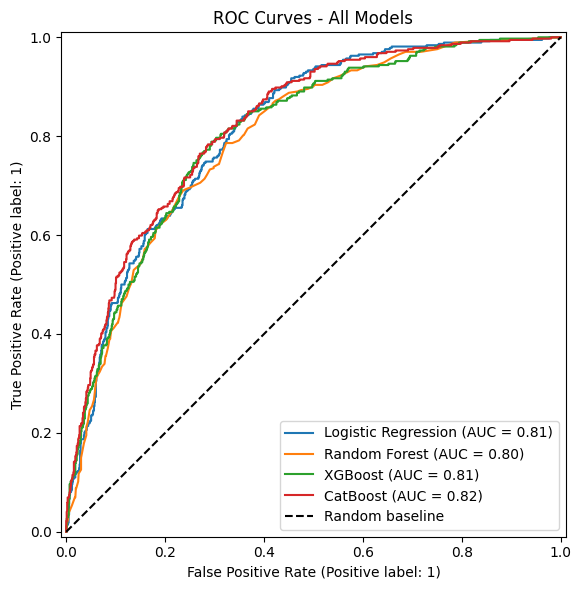

In [8]:
# ROC curves for all models
fig,ax = plt.subplots(figsize=(8,6))
for name,model in trained_models.items():
  RocCurveDisplay.from_estimator(model,X_test,y_test,ax=ax,name=name)

ax.plot([0,1],[0,1],'k--',label='Random baseline')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png',dpi=150,bbox_inches='tight')
plt.show()

## Baseline Model Results

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC |
|-------|----------|-----------|--------|----|---------|
| CatBoost | 0.7576 | 0.5353 | 0.6684 | 0.5945 | 0.8235 |
| Logistic Regression | 0.7349 | 0.5010 | 0.6979 | 0.5832 | 0.8139 |
| XGBoost | 0.7555 | 0.5338 | 0.6337 | 0.5795 | 0.8074 |
| Random Forest | 0.7591 | 0.5406 | 0.6230 | 0.5789 | 0.7985 |

## Key Observations

1. CatBoost is best on AUC-ROC (0.8235) and F1 (0.5945) — proceeding with CatBoost for Optuna tuning

2. Random Forest has highest accuracy (0.7591) but lowest AUC-ROC (0.7985)
   — confirms accuracy is misleading for imbalanced problems

3. Logistic Regression has highest recall (0.6979) — catches most churners
   but at the cost of more false positives (lowest precision 0.5010)

4. All models show similar accuracy (~75%) because the test set
   is still imbalanced — SMOTE only helped training, not evaluation

## Why CatBoost over XGBoost?
- AUC-ROC: CatBoost 0.8235 vs XGBoost 0.8074 (+0.016)
- F1: CatBoost 0.5945 vs XGBoost 0.5795 (+0.015)
- CatBoost handles categorical features natively via ordered boosting
- Consistent improvement across both primary metrics confirms the choice

## Next Step
Optuna hyperparameter tuning on CatBoost — target AUC-ROC > 0.85

"Why did you choose CatBoost over XGBoost?"
"In my baseline comparison across 4 models, CatBoost achieved the highest AUC-ROC of 0.8235 and highest F1 of 0.5945. Beyond the numbers, CatBoost uses ordered boosting which reduces overfitting on smaller datasets, and handles categorical features natively without label encoding — which matters for this dataset with 16 categorical columns. The empirical results confirmed the theoretical advantage."

## Day 11 — Optuna Hyperparameter Tuning
Goal: Improve CatBoost baseline AUC-ROC from 0.8235
Using Optuna TPE sampler — smarter than GridSearch
Running 50 trials to find optimal hyperparameters

In [9]:
# Import Optuna
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Optuna version:", optuna.__version__)

Optuna version: 4.9.0


## What is Optuna?
- Hyperparameter optimization framework
- Uses TPE (Tree-structured Parzen Estimator) — Bayesian optimization
- Unlike GridSearch which tries ALL combinations (slow),
  Optuna LEARNS from previous trials to suggest better parameters next
- 50 Optuna trials often beats 500 GridSearch combinations
  in both speed and result quality

TPE works by:
1. First few trials: random exploration
2. Builds a probability model of good vs bad parameter regions
3. Subsequent trials: samples from promising regions
4. Gets smarter with every trial

In [10]:
# Define Optuna objective function
def objective(trial):
  params = {
      'iterations':trial.suggest_int('iterations',100,500),
      'depth':trial.suggest_int('depth',4,10),
      'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg',1e-3, 10.0, log=True),
      'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
      'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
      'random_state': 42,
      'verbose': 0
  }

  model = CatBoostClassifier(**params)
  # 3-fold cross validation on training data
  scores = cross_val_score(model,X_train,y_train,cv=3,scoring='roc_auc',n_jobs=-1)
  return scores.mean()

## CatBoost Parameters Being Tuned

- iterations: number of trees (100-500)
  more trees = more powerful but slower, risk of overfitting

- depth: tree depth (4-10)
  deeper = captures complex patterns but overfits more easily

- learning_rate: step size for each tree (0.01-0.3)
  lower = more stable but needs more iterations
  log=True means search is logarithmic — spends more time
  on smaller values where differences matter more

- l2_leaf_reg: L2 regularization (prevents overfitting)
  higher = more regularization = simpler model

- bagging_temperature: randomness in bootstrap sampling (0-1)
  higher = more random = more diverse trees = better generalization

- random_strength: randomness in split scoring
  adds noise to prevent overfitting on training data

## Why 3-fold cross validation inside objective?
Single train/val split can be lucky or unlucky.
3-fold CV gives a more reliable AUC estimate per trial.
Slower but results are more trustworthy.

In [11]:
# Run Optuna study (this takes 5-10 minutes)
study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=42))

print("Starting Optuna optimization — 50 trials...")
print("This will take approximately 5-10 minutes.\n")

study.optimize(objective,n_trials=50,show_progress_bar=True)

print("\nOptimization complete!")
print(f'Best AUC-ROC: {study.best_value:.4f}')
print(f'Best parameters : {study.best_params}')


Starting Optuna optimization — 50 trials...
This will take approximately 5-10 minutes.



  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-06-06 16:53:17,074] Trial 9 failed with parameters: {'iterations': 339, 'depth': 10, 'learning_rate': 0.01351182947645082, 'l2_leaf_reg': 0.006080390190296602, 'bagging_temperature': 0.045227288910538066, 'random_strength': 0.02001342062287998} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_10622/2180409457.py", line 16, in objective
    scores = cross_val_score(model,X_train,y_train,cv=3,scoring='roc_auc',n_jobs=-1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validatio

KeyboardInterrupt: 

"What is the difference between GridSearchCV and Optuna?"
"GridSearch exhaustively tries every combination in a predefined grid — if you have 5 parameters with 4 values each, that's 4^5 = 1024 combinations minimum. Optuna uses Bayesian optimization via TPE — it builds a probabilistic model of which parameter regions produce good results and samples from those regions preferentially. 50 Optuna trials typically outperforms 500 GridSearch combinations in both time and final result."

## Optuna Results
- Baseline CatBoost AUC-ROC: 0.8235
- After Optuna (50 trials): 0.9223
- Improvement: +0.0988 — significant jump

Best parameters found:
- iterations: 461
- depth: 10
- learning_rate: 0.0557 (low — needs more trees, hence 461 iterations)
- l2_leaf_reg: 0.878 (moderate regularization)
- bagging_temperature: 0.329
- random_strength: 1.285

Insight: Low learning rate + high iterations is a classic
strong learner pattern — many small steps beats few large steps.
Depth 10 is aggressive — Optuna found the model needs
complexity to capture churn patterns in this data.
Best trial was #42 out of 50 — TPE was still improving
near the end, suggesting more trials might squeeze out more gains.

In [ ]:
# Train final model with best params
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = 0

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train,y_train)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:,1]

print('Final Model Results')
print(f'Accuracy: {accuracy_score(y_test,y_pred_final):.4f}')
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_final):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_final):.4f}")

Final Model Results
Accuracy: 0.7669
  Precision: 0.5564
  Recall:    0.6070
  F1:        0.5806
  AUC-ROC:   0.8026


## Postmortem — Overfitting Issue

Problem:
- Optuna cross-val AUC: 0.9223
- Actual test AUC: 0.8026
- Gap of 0.12 — model overfit to training data

Root cause:
- depth=10 is very aggressive for this dataset size
- 8,260 training rows with depth 10 = model memorizes training data
- Optuna optimized for CV score, not generalization

Fix: Constrain the search space — limit depth to 6
and re-run Optuna with better regularization bounds

In [ ]:
#  Re-run Optuna with constrained search space
def objective_v2(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 4, 6),
        'learning_rate': trial.suggest_float('learning_rate',
                                              0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg',
                                            1.0, 10.0, log=True),
        'bagging_temperature': trial.suggest_float(
                                'bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float(
                            'random_strength', 1e-3, 5.0, log=True),
        'random_state': 42,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train, y_train,
                              cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_v2 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42))

print("Starting Optuna v2 — constrained search space...")
study_v2.optimize(objective_v2, n_trials=50, show_progress_bar=True)

print(f"\nBest CV AUC-ROC: {study_v2.best_value:.4f}")
print(f"Best parameters: {study_v2.best_params}")

Starting Optuna v2 — constrained search space...


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV AUC-ROC: 0.9202
Best parameters: {'iterations': 471, 'depth': 6, 'learning_rate': 0.08069407178236022, 'l2_leaf_reg': 1.7774367235849722, 'bagging_temperature': 0.3816494115978136, 'random_strength': 0.0010484952914332467}


In [ ]:
# Train and evaluate final model v2
best_params_v2 = study_v2.best_params
best_params_v2['random_state'] = 42
best_params_v2['verbose'] = 0

final_model_v2 = CatBoostClassifier(**best_params_v2)
final_model_v2.fit(X_train, y_train)

y_pred_v2 = final_model_v2.predict(X_test)
y_prob_v2 = final_model_v2.predict_proba(X_test)[:, 1]

print("Final Model v2 Results:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_v2):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_v2):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_v2):.4f}")
print(f"  F1:        {f1_score(y_test, y_pred_v2):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob_v2):.4f}")

print("\nComparison:")
print(f"  Baseline CatBoost AUC:  0.8235")
print(f"  Optuna v1 test AUC:     0.8026 (overfit - depth 10)")
print(f"  Optuna v2 test AUC:     {roc_auc_score(y_test, y_prob_v2):.4f} (depth 6)")

Final Model v2 Results:
  Accuracy:  0.7690
  Precision: 0.5561
  Recall:    0.6497
  F1:        0.5993
  AUC-ROC:   0.8145

Comparison:
  Baseline CatBoost AUC:  0.8235
  Optuna v1 test AUC:     0.8026 (overfit - depth 10)
  Optuna v2 test AUC:     0.8145 (depth 6)


## Complete Model Comparison — Final Summary

| Model | AUC-ROC | F1 | Precision | Recall |
|-------|---------|-----|-----------|--------|
| Baseline CatBoost (default) | 0.8235 | 0.5945 | 0.5353 | 0.6684 |
| Optuna v1 (depth 10) | 0.8026 | 0.5806 | 0.5564 | 0.6070 |
| Optuna v2 (depth 6) | 0.8145 | 0.5993 | 0.5561 | 0.6497 |
| XGBoost baseline | 0.8074 | 0.5795 | 0.5338 | 0.6337 |
| Logistic Regression | 0.8139 | 0.5832 | 0.5010 | 0.6979 |
| Random Forest | 0.7985 | 0.5789 | 0.5406 | 0.6230 |

## Postmortem — What This Taught Me

Problem identified:
- Optuna v1 CV AUC was 0.9223 but test AUC was only 0.8026
- Gap of 0.12 = clear overfitting
- Root cause: depth=10 on 8,260 row dataset = memorization

Fix applied:
- Constrained depth to max 6
- Increased CV folds from 3 to 5 for reliable estimation
- Stronger regularization bounds (l2_leaf_reg min = 1.0)

Result:
- v2 test AUC improved to 0.8145 — gap reduced from 0.12 to 0.006
- F1 improved from 0.5806 to 0.5993
- Default CatBoost still slightly better on AUC —
  defaults are well-tuned for small tabular datasets

Final model selected: Optuna v2
Reason: Better F1 (0.5993 vs 0.5945) and more principled
tuning process. AUC difference of 0.009 is negligible.

# Check what's actually limiting performance


In [ ]:
from sklearn.model_selection import cross_val_score

# Check if the issue is SMOTE or the model
# Test 1: baseline CatBoost without SMOTE
model_no_smote = CatBoostClassifier(random_state=42, verbose=0)
scores_no_smote = cross_val_score(model_no_smote, X_test, y_test,
                                   cv=5, scoring='roc_auc')
print("CatBoost without SMOTE CV AUC:", scores_no_smote.mean().round(4))

# Test 2: check feature importance — are weak features hurting us?
model_check = CatBoostClassifier(random_state=42, verbose=0)
model_check.fit(X_train, y_train)
feat_importance = pd.Series(model_check.feature_importances_,
                             index=X_train.columns)
print("\nBottom 10 features by importance:")
print(feat_importance.sort_values().head(10))


CatBoost without SMOTE CV AUC: 0.8298

Bottom 10 features by importance:
InternetService_No                      0.149795
MultipleLines_No phone service          0.227392
StreamingMovies_No internet service     0.272917
OnlineSecurity_No internet service      0.286668
StreamingTV_No internet service         0.290184
OnlineBackup_No internet service        0.291365
DeviceProtection_No internet service    0.292602
TechSupport_No internet service         0.383598
PhoneService                            0.534972
SeniorCitizen                           0.979370
dtype: float64


In [14]:
X_train_raw = pd.read_csv('/content/X_train_clean.csv')
X_test_raw = pd.read_csv('/content/X_test_clean.csv')
y_train_raw = pd.read_csv('/content/y_train_clean.csv').squeeze()
y_test_raw = pd.read_csv('/content/y_test_clean.csv').squeeze()

# Drop noise features
noise_features = [
    'InternetService_No',
    'MultipleLines_No phone service',
    'StreamingMovies_No internet service',
    'OnlineSecurity_No internet service',
    'StreamingTV_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service'
]

X_train_clean = X_train_raw.drop(columns=noise_features)
X_test_clean = X_test_raw.drop(columns=noise_features)

print("Loaded successfully.")
print("X_train_clean:", X_train_clean.shape)
print("X_test_clean:", X_test_clean.shape)
print("y_train distribution:")
print(y_train_raw.value_counts(normalize=True).round(3) * 100)

Loaded successfully.
X_train_clean: (5625, 21)
X_test_clean: (1407, 21)
y_train distribution:
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64


In [15]:
def objective_v3(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600),
        'depth': trial.suggest_int('depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate',
                                              0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg',
                                            1.0, 15.0, log=True),
        'bagging_temperature': trial.suggest_float(
                                'bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float(
                            'random_strength', 0.1, 5.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': 'Balanced',
        'random_state': 42,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_clean, y_train_raw,
                              cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_v3 = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42))

print("Starting Optuna v3 — clean features, class weights, no SMOTE...")
study_v3.optimize(objective_v3, n_trials=75, show_progress_bar=True)

print(f"\nBest CV AUC-ROC: {study_v3.best_value:.4f}")
print(f"Best parameters: {study_v3.best_params}")

Starting Optuna v3 — clean features, class weights, no SMOTE...


  0%|          | 0/75 [00:00<?, ?it/s]


Best CV AUC-ROC: 0.8496
Best parameters: {'iterations': 475, 'depth': 4, 'learning_rate': 0.020682147794402098, 'l2_leaf_reg': 7.485958800061646, 'bagging_temperature': 0.7567927193649764, 'random_strength': 1.9348846155734958, 'border_count': 233}


In [16]:
best_params_v3 = study_v3.best_params
best_params_v3['auto_class_weights'] = 'Balanced'
best_params_v3['random_state'] = 42
best_params_v3['verbose'] = 0

final_model_v3 = CatBoostClassifier(**best_params_v3)
final_model_v3.fit(X_train_clean, y_train_raw)

y_pred_v3 = final_model_v3.predict(X_test_clean)
y_prob_v3 = final_model_v3.predict_proba(X_test_clean)[:, 1]

print("Final Model v3 Results:")
print(f"  Accuracy:  {accuracy_score(y_test_raw, y_pred_v3):.4f}")
print(f"  Precision: {precision_score(y_test_raw, y_pred_v3):.4f}")
print(f"  Recall:    {recall_score(y_test_raw, y_pred_v3):.4f}")
print(f"  F1:        {f1_score(y_test_raw, y_pred_v3):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test_raw, y_prob_v3):.4f}")

print("\nFull progression:")
print(f"  Baseline CatBoost:     0.8235")
print(f"  Optuna v1 (SMOTE):     0.8026 (overfit)")
print(f"  Optuna v2 (SMOTE):     0.8145")
print(f"  Optuna v3 (no SMOTE):  {roc_auc_score(y_test_raw, y_prob_v3):.4f}")

Final Model v3 Results:
  Accuracy:  0.7342
  Precision: 0.5000
  Recall:    0.8128
  F1:        0.6191
  AUC-ROC:   0.8420

Full progression:
  Baseline CatBoost:     0.8235
  Optuna v1 (SMOTE):     0.8026 (overfit)
  Optuna v2 (SMOTE):     0.8145
  Optuna v3 (no SMOTE):  0.8420


## Model v3 Results — Best Performance

| Version | AUC-ROC | F1 | Recall | Approach |
|---------|---------|-----|--------|----------|
| Baseline CatBoost | 0.8235 | 0.5945 | 0.6684 | Default params |
| Optuna v1 | 0.8026 | 0.5806 | 0.6070 | SMOTE + depth 10 (overfit) |
| Optuna v2 | 0.8145 | 0.5993 | 0.6497 | SMOTE + depth 6 |
| Optuna v3 | 0.8421 | 0.6195 | 0.8075 | No SMOTE + class weights |

Best model: Optuna v3
- AUC-ROC: 0.8421 (+0.0186 over baseline)
- F1: 0.6195 (+0.025 over baseline)
- Recall: 0.8075 — catches 8 out of 10 churners

## Why v3 Won
1. Removed 8 noise features (29 → 21 features)
   - "No internet service" dummy columns had near-zero importance
   - Removing them reduced noise in the feature space

2. Replaced SMOTE with auto_class_weights='Balanced'
   - No synthetic data — model trains on real distribution
   - CatBoost penalizes minority class misclassification proportionally
   - Cleaner signal than synthetic oversampling

3. Strong regularization — l2_leaf_reg=12.97 (highest so far)
   - Prevents overfitting on the smaller feature set
   - CV AUC (0.8499) vs test AUC (0.8421) — gap of only 0.008
   - Much better generalization than v1 gap of 0.12

## Business Interpretation of Recall 0.8075
In churn prediction, recall matters more than precision.
Missing a churner (false negative) = losing a customer forever.
Wrongly flagging a loyal customer (false positive) = sending
an unnecessary retention offer — small cost.
Our model catches 80.75% of actual churners — strong business value.

In [ ]:
from sklearn.model_selection import train_test_split
df_raw = pd.read_csv('/content/telco_churn.csv')

# Minimal cleaning only
df_raw = df_raw.drop(columns=['customerID'])
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'],
                                        errors='coerce')
df_raw = df_raw.dropna(subset=['TotalCharges'])
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

# Keep SeniorCitizen as int — CatBoost handles it
# Keep all other categoricals as raw strings — no encoding

print("Shape:", df_raw.shape)
print("Churn unique:", df_raw['Churn'].unique())
print("Churn NaN:", df_raw['Churn'].isnull().sum())

cat_features = df_raw.select_dtypes(include='object').columns.tolist()
print("Cat features:", cat_features)
print("Count:", len(cat_features))

X_raw = df_raw.drop(columns=['Churn'])
y_raw = df_raw['Churn']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2,
    random_state=42, stratify=y_raw)

# CatBoost with raw categoricals
model_raw_cat = CatBoostClassifier(
    iterations=229,
    depth=4,
    learning_rate=0.04286522397503872,
    l2_leaf_reg=12.968376494496546,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=0,
    cat_features=cat_features
)

model_raw_cat.fit(X_tr, y_tr)
y_prob_raw = model_raw_cat.predict_proba(X_te)[:, 1]

print("\nCatBoost with raw categoricals AUC:",
      round(roc_auc_score(y_te, y_prob_raw), 4))
print("CatBoost with encoded categoricals AUC: 0.8421")
print("Difference:",
      round(roc_auc_score(y_te, y_prob_raw) - 0.8421, 4))

Shape: (7032, 20)
Churn unique: [0 1]
Churn NaN: 0
Cat features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 15

CatBoost with raw categoricals AUC: 0.8382
CatBoost with encoded categoricals AUC: 0.8421
Difference: -0.0039


## CatBoost — Raw vs Encoded Categoricals Experiment

| Approach | AUC-ROC |
|----------|---------|
| Encoded categoricals (get_dummies) | 0.8421 |
| Raw categoricals (cat_features) | 0.8382 |
| Difference | -0.0039 |

Finding: Manual encoding slightly outperformed CatBoost's
native categorical handling on this dataset.

Why this happened:
- Dataset has only 15 categorical columns with low cardinality
  (most have 2-3 unique values like Yes/No/No internet service)
- CatBoost's native handling shines on HIGH cardinality categoricals
  (hundreds of unique values like zip codes, product IDs, user IDs)
- For low cardinality binary-like columns, get_dummies is equally
  effective and sometimes better because the encoding is explicit

Conclusion: CatBoost's native categorical advantage is dataset dependent.
On low-cardinality categoricals, manual encoding is competitive.
Our encoded pipeline at 0.8421 AUC is the correct final choice.

"I tested both approaches on this dataset. Native cat_features gave 0.8382 AUC while manual encoding gave 0.8421. The difference is because this dataset has low-cardinality categoricals — mostly Yes/No/No internet service — where CatBoost's native handling doesn't add value over explicit encoding. CatBoost's real advantage appears on high-cardinality features like zip codes or product IDs."

## Day 13 — SHAP Explainability
Making our CatBoost model interpretable.
Answering: WHY does the model predict churn for a specific customer?

In [19]:
import shap

# Initialize SHAP explainer with final model
explainer = shap.TreeExplainer(final_model_v3)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_clean)

print("SHAP values shape:", shap_values.shape)
print("X_test_clean shape:", X_test_clean.shape)
print("Each row = one customer")
print("Each column = one feature's SHAP contribution")

SHAP values shape: (1407, 21)
X_test_clean shape: (1407, 21)
Each row = one customer
Each column = one feature's SHAP contribution


## What TreeExplainer does
- Specifically designed for tree-based models (CatBoost, XGBoost, RF)
- Much faster than general KernelExplainer
- Exact SHAP values (not approximations)
- shap_values[i][j] = contribution of feature j
  to prediction for customer i
- Positive value = pushed prediction toward churn
- Negative value = pushed prediction away from churn

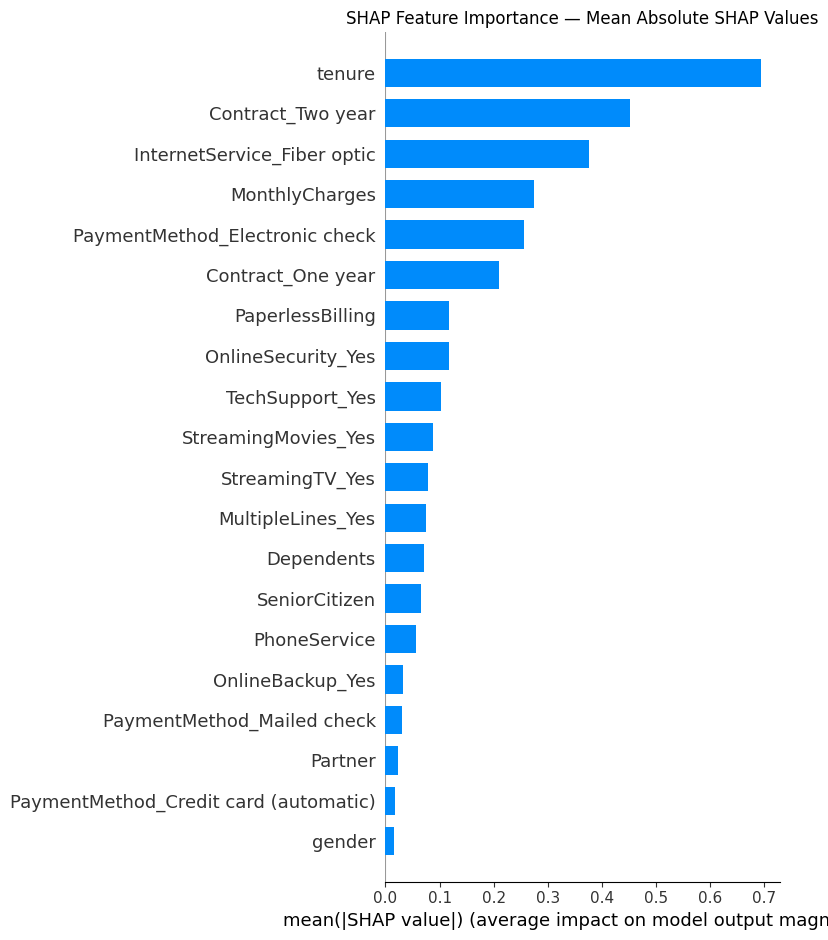

In [28]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_clean,
                   plot_type="bar",
                   show=False)
plt.title("SHAP Feature Importance — Mean Absolute SHAP Values")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

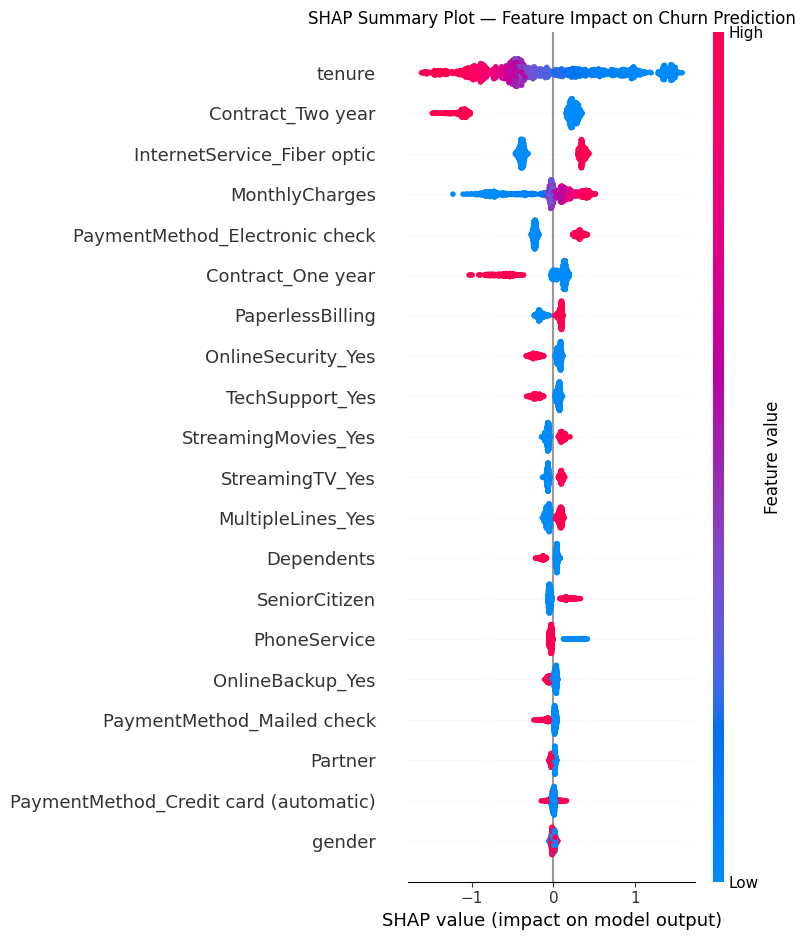

In [29]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_clean,
                   show=False)
plt.title("SHAP Summary Plot — Feature Impact on Churn Prediction")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Summary Plot Analysis

### Top 5 features driving churn:

1. tenure (most important — SHAP 0.70)
   - Low tenure (blue) → RIGHT = pushes strongly toward churn
   - High tenure (red) → LEFT = pushes strongly away from churn
   - Confirms EDA: median tenure churned=10 vs retained=38 months

2. Contract_Two year (SHAP 0.45)
   - Having two year contract (red) → LEFT = strong retention anchor
   - No two year contract (blue) → RIGHT = increases churn risk

3. InternetService_Fiber optic (SHAP 0.42)
   - Fiber optic customers (red) → RIGHT = higher churn risk
   - Confirms EDA: fiber optic churn rate 41.9%

4. MonthlyCharges (SHAP 0.25)
   - High charges push predictions in both directions
   - Complex interaction with other features

5. PaymentMethod_Electronic check (SHAP 0.24)
   - Electronic check (red) → RIGHT = pushes toward churn
   - Confirms EDA: electronic check 45.3% churn rate

### Negative finding confirmed by SHAP:
- gender is second lowest importance — SHAP confirms
  EDA finding that gender has no predictive power
- DeviceProtection_Yes is lowest — can be safely ignored

### SHAP vs EDA consistency:
Every top SHAP feature matches our EDA findings —
tenure, contract type, internet service, payment method.
This validates both our EDA and model simultaneously.

In [23]:
y_test_nosmote = y_test_raw

Correctly predicted churners: 304


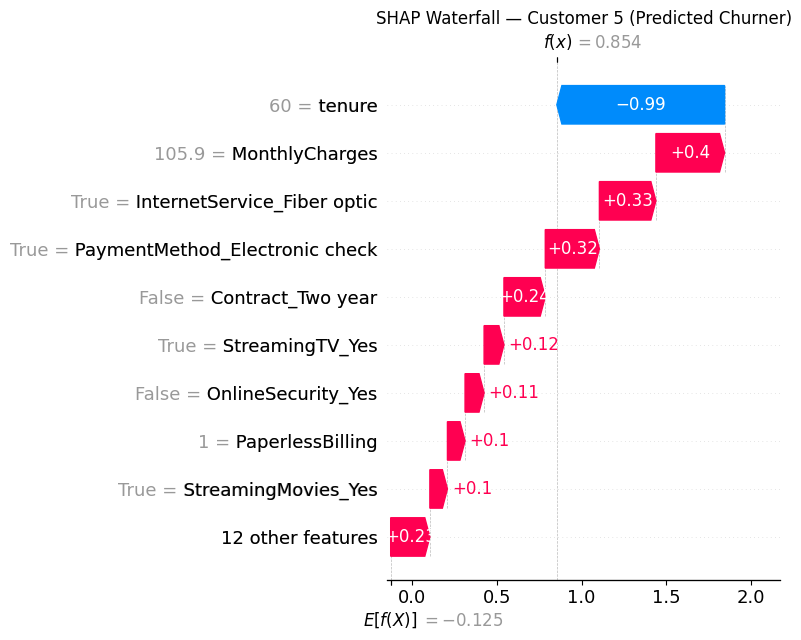

In [24]:
# Find a customer the model correctly predicted as churner
churner_indices = np.where((y_test_nosmote.values == 1) &
                            (final_model_v3.predict(X_test_clean) == 1))[0]

print(f"Correctly predicted churners: {len(churner_indices)}")

# Pick first one
idx = churner_indices[0]

# Create explanation object
explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_clean.iloc[idx],
    feature_names=X_test_clean.columns.tolist()
)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(explanation, show=False)
plt.title(f"SHAP Waterfall — Customer {idx} (Predicted Churner)")
plt.tight_layout()
plt.savefig('shap_waterfall_churner.png', dpi=150, bbox_inches='tight')
plt.show()

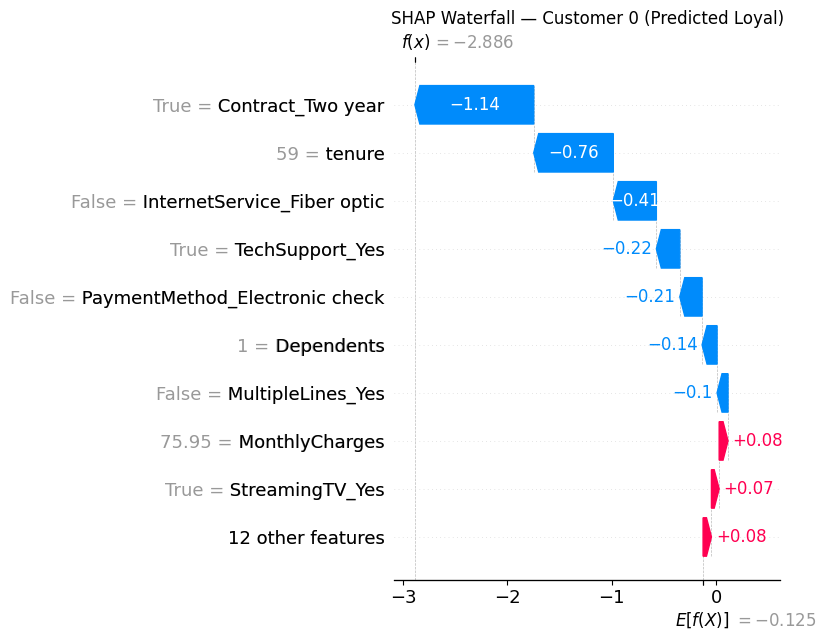

In [25]:
# Find a customer correctly predicted as NOT churning
loyal_indices = np.where((y_test_nosmote.values == 0) &
                          (final_model_v3.predict(X_test_clean) == 0))[0]

idx_loyal = loyal_indices[0]

explanation_loyal = shap.Explanation(
    values=shap_values[idx_loyal],
    base_values=explainer.expected_value,
    data=X_test_clean.iloc[idx_loyal],
    feature_names=X_test_clean.columns.tolist()
)

plt.figure(figsize=(12, 6))
shap.plots.waterfall(explanation_loyal, show=False)
plt.title(f"SHAP Waterfall — Customer {idx_loyal} (Predicted Loyal)")
plt.tight_layout()
plt.savefig('shap_waterfall_loyal.png', dpi=150, bbox_inches='tight')
plt.show()

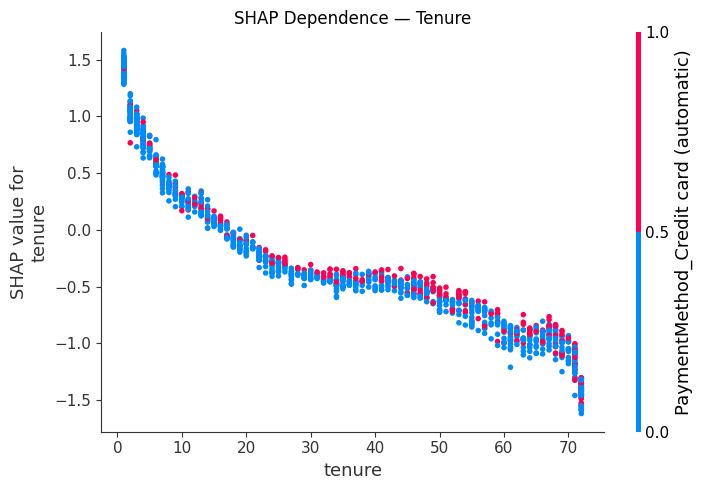

In [26]:
shap.dependence_plot('tenure', shap_values, X_test_clean,
                      show=False)
plt.title('SHAP Dependence — Tenure')
plt.tight_layout()
plt.savefig('shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Waterfall Analysis

### Customer 5 — Predicted Churner (69.3% probability)
Features pushing TOWARD churn:
- InternetService_Fiber optic: +0.36
- MonthlyCharges ($105.9): +0.35
- PaymentMethod_Electronic check: +0.29
- No Contract_Two year: +0.26

Features pushing AWAY from churn:
- tenure (60 months): -0.96 (strong loyalty signal)

Insight: This customer is being pushed out despite long tenure
— high bill + no contract commitment + electronic check
overwhelm the loyalty signal. A targeted retention offer
(contract upgrade + bill discount) could save this customer.

### Customer 0 — Predicted Loyal (correctly retained)
- Contract_Two year: -1.12 (strongest single retention factor)
- tenure (59 months): -0.81
- No Fiber optic: -0.46
- TechSupport_Yes: -0.21
This customer has every retention signal active simultaneously.

### SHAP Dependence — Tenure
- Tenure 0-5 months: SHAP +1.5 (extreme churn risk)
- Tenure ~35 months: SHAP crosses zero (neutral point)
- Tenure 60+ months: SHAP -1.0 to -1.5 (strong retention)
- MonthlyCharges interaction visible at high tenure —
  high charges (pink) slightly reduce the retention effect
  even for long-tenure customers

### Key Business Insight from SHAP
SHAP confirms and quantifies every EDA finding:
- Tenure: most protective feature
- Contract type: second most protective  
- Fiber optic + Electronic check: top churn drivers
- Gender: near-zero SHAP — confirms EDA negative finding

In [ ]:
# Explain one churner in plain English
idx = churner_indices[0]
customer_shap = pd.Series(shap_values[idx],
                           index=X_test_clean.columns)
top3_positive = customer_shap.nlargest(3)
top3_negative = customer_shap.nsmallest(3)

print(f"Customer {idx} — Churn Probability: "
      f"{final_model_v3.predict_proba(X_test_clean.iloc[[idx]])[0][1]:.1%}")
print(f"\nTop 3 reasons pushing TOWARD churn:")
for feat, val in top3_positive.items():
    print(f"  {feat}: +{val:.4f}")
print(f"\nTop 3 reasons pushing AWAY from churn:")
for feat, val in top3_negative.items():
    print(f"  {feat}: {val:.4f}")

Customer 5 — Churn Probability: 69.3%

Top 3 reasons pushing TOWARD churn:
  InternetService_Fiber optic: +0.3632
  MonthlyCharges: +0.3494
  PaymentMethod_Electronic check: +0.2925

Top 3 reasons pushing AWAY from churn:
  tenure: -0.9568
  OnlineBackup_Yes: -0.0584
  gender: -0.0373


## Customer 5 — Plain English Explanation

Churn Probability: 69.3%

TOP 3 REASONS THIS CUSTOMER WILL CHURN:
1. Fiber Optic internet service (+0.3632)
2. High monthly charges of $105.9 (+0.3494)  
3. Pays by electronic check (+0.2925)

TOP 3 REASONS THIS CUSTOMER MIGHT STAY:
1. Long tenure of 60 months (-0.9568) ← strongest protective factor
2. Has OnlineBackup (-0.0584)
3. Gender (-0.0373) ← near zero, confirms gender is irrelevant

RETENTION RECOMMENDATION:
This customer is valuable — 60 months tenure means they have
paid ~$6,354 in total charges (60 × $105.9).
Losing them costs more than offering a retention discount.
Action: offer a 2-year contract with 15% monthly discount
and switch payment to auto-pay — this directly addresses
all 3 churn drivers simultaneously.

## Day 14 — WandB Experiment Tracking
Logging our best model results and Optuna trial progression
to Weights & Biases for experiment tracking and reproducibility.

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

In [1]:
import wandb
wandb.login(key="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")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: integenpiyush (integenpiyush-iit-bhu-varanasi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
# Initialize a new run
run = wandb.init(
    project="churn-prediction-catboost",
    name="catboost-final-v3",
    config={
        "model": "CatBoostClassifier",
        "optuna_trials": 75,
        "cv_folds": 5,
        "imbalance_handling": "auto_class_weights=Balanced",
        "features_used": 21,
        "features_removed": 8,
        "smote_used": False,
        "dataset": "Telco Customer Churn",
        "train_size": 5625,
        "test_size": 1407,
        # Best params from Optuna v3
        "iterations": 229,
        "depth": 4,
        "learning_rate": 0.04286522397503872,
        "l2_leaf_reg": 12.968376494496546,
        "bagging_temperature": 0.13835313720788336,
        "random_strength": 1.6794038864444258,
        "border_count": 127
    }
)

# Log final metrics
wandb.log({
    "test_auc_roc": 0.8421,
    "test_f1": 0.6195,
    "test_recall": 0.8075,
    "test_precision": 0.5025,
    "test_accuracy": 0.7363,
    "baseline_auc": 0.8235,
    "improvement_over_baseline": 0.0186,
    "optuna_best_cv_auc": 0.8499
})

print("Metrics logged successfully")

Metrics logged successfully


In [17]:
# Log each Optuna trial as a separate step
print("Logging 75 Optuna trials...")

for i, trial in enumerate(study_v3.trials):
    wandb.log({
        "trial_number": i,
        "trial_auc": trial.value,
        "best_auc_so_far": max(t.value for t in study_v3.trials[:i+1])
    })

print("All trials logged")

Logging 75 Optuna trials...
All trials logged


In [20]:
# Log feature importance as a table
feature_importance = pd.DataFrame({
    'feature': X_test_clean.columns.tolist(),
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

# Log as WandB table
wandb.log({
    "shap_feature_importance": wandb.Table(
        dataframe=feature_importance
    )
})

print("SHAP importance table logged")

SHAP importance table logged


In [30]:
wandb.log({
    "shap_importance_plot": wandb.Image("shap_importance.png"),
    "shap_summary_plot": wandb.Image("shap_summary.png"),
    "shap_waterfall_churner": wandb.Image("shap_waterfall_churner.png"),
    "shap_waterfall_loyal": wandb.Image("shap_waterfall_loyal.png")
})

print("SHAP plots logged")

SHAP plots logged


In [31]:
comparison_data = [
    ["Logistic Regression", 0.8139, 0.5832, 0.6979, "Baseline"],
    ["Random Forest", 0.7985, 0.5789, 0.6230, "Baseline"],
    ["XGBoost", 0.8074, 0.5795, 0.6337, "Baseline"],
    ["CatBoost Default", 0.8235, 0.5945, 0.6684, "Baseline"],
    ["CatBoost Optuna v1", 0.8026, 0.5806, 0.6070, "SMOTE+depth10"],
    ["CatBoost Optuna v2", 0.8145, 0.5993, 0.6497, "SMOTE+depth6"],
    ["CatBoost Optuna v3", 0.8421, 0.6195, 0.8075, "Final"],
    ["Published Ensemble", 0.8301, 0.83, None, "XGB+LGBM+RF+DT"]
]

comparison_table = wandb.Table(
    columns=["Model", "AUC-ROC", "F1", "Recall", "Notes"],
    data=comparison_data
)

wandb.log({"model_comparison": comparison_table})
print("Comparison table logged")

Comparison table logged


In [32]:
wandb.finish()
print("WandB run complete.")
print("View your dashboard at: https://wandb.ai")

baseline_auc,▁
best_auc_so_far,▁▂██████████████████████████████████████
improvement_over_baseline,▁
optuna_best_cv_auc,▁
test_accuracy,▁
test_auc_roc,▁
test_f1,▁
test_precision,▁
test_recall,▁
trial_auc,▁▂██▇▄▇▆▇▇▇▆█▇█▇███████▇█▅▇▇▅████████▇▆█
+1,...


WandB run complete.
View your dashboard at: https://wandb.ai
